## PaleoExfiltration Model Code ##

##### This code has been adapted from Robel et al. (2023). 

### Load in packages to run hydromechanical model and plot ###

In [140]:
# Load in necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as spr
from scipy.sparse.linalg import inv
from pyproj import Proj, transform
import cartopy.feature as cfeature

### Load in thickness-time series data and determine the duration for each site ###

In [141]:
# Loading in the interpolated data frame produced in the 'BayesianSplineandSensitivityTest.ipynb'
file_path ='thicknesstimeserieslowerCI.csv' # or could be 'thicknesstimeseriesupperCI.csv' or 'thicknesstimeserieslowerCI.csv'
interpolated_df = pd.read_csv(file_path)

# Calculate the duration for each site
duration_tf = interpolated_df.groupby('Site').agg(
    Start_Age=('Age', 'max'),
    End_Age=('Age', 'min'),
    Duration=('Age', lambda x: x.max() - x.min())
).reset_index()

# Display the first few rows of the duration data; 'Start_Age' should be 20,000 and 'End_Age' should be 0
duration_tf

,Site,Start_Age,End_Age,Duration
0,4,20000,0,20000
1,7,20000,0,20000
2,11,20000,0,20000
3,15,20000,0,20000
4,17,20000,0,20000
...,...,...,...,...
56,152,20000,0,20000
57,156,20000,0,20000
58,161,20000,0,20000
59,164,20000,0,20000


### Count the number of unique sites in the dataset

In [229]:
num_unique_sites = interpolated_df['Site'].nunique()
num_unique_sites

61

## Specify a site number to produce a thickness vs elevation vs time plot for (optional)

In [143]:
# This code block can be helpful if you want to look at the thickness-time series of a specific site 

# Set the site number 
site = 129  # Specify the site number
site_data = interpolated_df[interpolated_df['Site'] == site]

# Interpolate thickness data to match the time steps
f_interp = np.interp(t/year, site_data['Age'], site_data['Thickness'])

# Extract latitude and longitude
site_lat = site_data['Latm'].values[0]  # Latitude of the site
site_lon = site_data['Lonm'].values[0]  # Longitude of the site

## Parameters

In [230]:
intSave=100
year = 3600*24*365

#xi is dimensionless loading efficiency(Skempton's constant)
xi = 0.2

#rhoi is the density of glacier ice (kg/m3)
rhoi = 920

#rhow is density of water
rhow = 1000

#g is acceleration due to gravity (m/s2)
g = 9.81

#mu_w is the viscosity of water (Pa*s)
mu_w = 1e-3

#S is sediment specific storage capacity (m-1)
S = 1e-4

#permeability
perm=1e-14

#K_t is the hydraulic conductivity (function of perm which we assume stays constant over time)
K_t = perm*rhow*g/mu_w

D = K_t/S

#H_init is the initial thickness of overlying glacier ice (m)
h_init = site_data['Thickness'].max()

# Calculate dh as the total change in ice thickness for the site
dh = site_data['Thickness'].max() - site_data['Thickness'].min()

## Grids and pre-allocation

In [199]:
# Define the length of the domain (L) in meters. In this case, it's 40 km (40,000 meters).
L = 40e3

# Set the number of grid points (nx) to 1001
nx = int(1e3 + 1) # Make it smaller to make the grid coarser 

# Generate a linearly spaced array (x) from 0 to L, with nx points.
# This array represents the spatial coordinates across the domain.
x = np.linspace(0, L, num=nx)

# Calculate the grid spacing (dx) as the difference between consecutive points in the x array.
dx = x[1] - x[0]

# Set a diffusion coefficient (C_D) to 1, which is a dimensionless parameter used in the time step calculation.
C_D = 1

# Calculate the time step (dt) based on the grid spacing (dx) and a given diffusion constant (D).
# The time step is determined by the stability criterion for the diffusion equation.
dt = (dx**2) * C_D / D # Make the time step longer by changing nx.

# Define the total simulation time (tf) in seconds
tf = (site_data['Age'].max() - site_data['Age'].min())#How many years we want the simulation to be 

# Calculate the total number of time steps (nt) based on the total time (tf) and the time step (dt).
# The result is rounded and then increased by 1 to account for the initial time step.
#nt = int(np.round(tf / dt) + 1)
nt = len(site_data)

# Generate a linearly spaced array (t) from 0 to tf, with nt points.
# This array represents the time steps across the entire simulation period.
#t = np.linspace(0, tf, num=nt) # Vector that goes over the years you want to simulate. 
t = site_data['Age'].values

# Initialize the hydraulic pressure head (h) within the sediment.
# The initial head (h_init) is scaled by the ratio of ice density (rhoi) to water density (rhow)
# and is uniformly applied across the entire domain (nx points).
h = h_init * (rhoi / rhow) * np.ones(nx)

# Create an array (h_all) to store the hydraulic pressure head values at each time step for the entire domain.
# The array has dimensions [nx, int(nt/intSave)+1], where intSave is a variable controlling the frequency of saving data.
h_all = np.zeros([nx, int(nt/intSave) + 1])

# Store the initial hydraulic pressure head (h) in the first column of h_all.
h_all[:, 0] = h

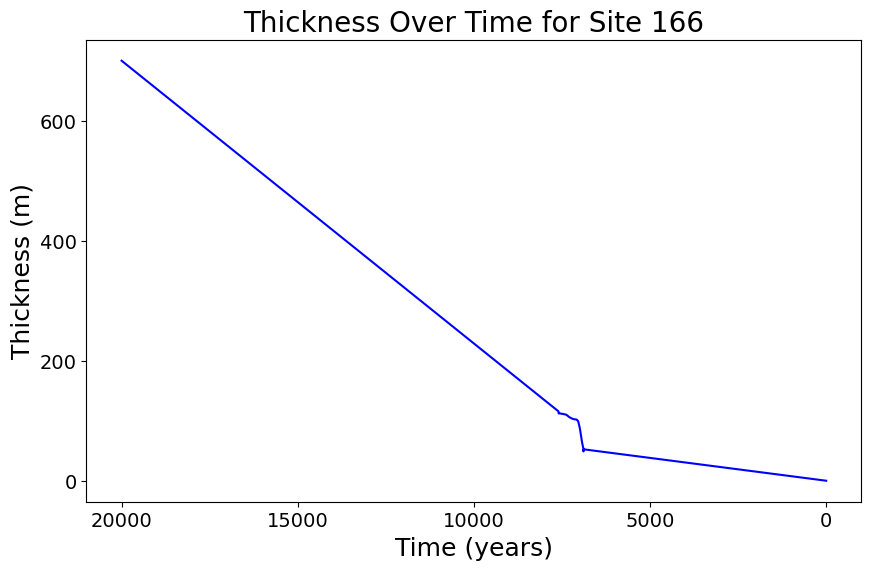

In [200]:
#this is where we'll change the time domain to geologic timescales-so eventually 20,000 years 
#ramp_time = 20 #in years

# Initialize an array to store the ice surface height at different time steps
#hbc_sfc  = np.zeros(int(nt)); #nt is the total number of time steps 
hbc_sfc = site_data['Thickness'].values

#change in ice surface height with time
dhdt = np.zeros_like(hbc_sfc)

# Create boolean masks to identify the time before and after the ramp time
#bramp_bool = t < ramp_time*year #before ramp time
#aramp_bool = t >= ramp_time*year #after ramp time 

# For times before the ramp, linearly decrease the ice surface height from initial height h_init to h_init - dh
#hbc_sfc[bramp_bool] = np.linspace(h_init,h_init-dh,np.count_nonzero(bramp_bool, axis=None))

# For times after the ramp, keep the ice surface height constant at h_init - dh
#hbc_sfc[aramp_bool] = h_init-dh;

# Calculate the rate of change of ice surface height over time by taking the difference between consecutive time steps
dhdt[1:] = np.diff(hbc_sfc)/dt

#Optional: Uncommenting the following lines would instead set dhdt to a linear decrease over the ramp period
#dhdt[bramp_bool] = -np.linspace(0,2*dh/ramp_time,np.count_nonzero(bramp_bool, axis=None))/year
#hbc_sfc = h_init + np.cumsum(dhdt*dt)

plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'], site_data['Thickness'], color='blue')
plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
plt.ylabel('Thickness (m)', fontsize=18)  # Increase the font size
plt.title(f'Thickness Over Time for Site {site}', fontsize=20)  # Increase the font size
plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# Customize ticks
plt.xticks(fontsize=14)  # Set x-axis tick font size
plt.yticks(fontsize=14)  # Set y-axis tick font size

# Reduce the number of ticks
plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

plt.show()

## Solve with Crank-Nicolson method

In [201]:
# Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the left-side matrix (Ml)
Mld = np.zeros([3,nx])

# Set the first and third rows of the matrix to be -0.5*C_D for all columns
Mld[0, :] = -0.5 * C_D * np.ones(nx)  # Upper diagonal
Mld[2, :] = -0.5 * C_D * np.ones(nx)  # Lower diagonal

# Set the second row of the matrix to be (1+C_D) for all columns
Mld[1, :] = (1 + C_D) * np.ones(nx)  # Main diagonal

# Create a sparse matrix (Ml) using the diagonals in Mld with offsets -1, 0, and 1
Ml = spr.spdiags(Mld, [-1, 0, 1], nx, nx)

# Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
Ml = spr.csc_matrix(Ml)

# Modify specific elements in the sparse matrix to enforce boundary conditions
Ml[-1, -1] = 1 + 0.5 * C_D  # Adjust the last element on the main diagonal
Ml[0, 1] = 0  # Set the first off-diagonal element to zero
Ml[0, 0] = 1  # Set the first element on the main diagonal to one

# Compute the inverse of the left-side matrix (Ml)
iMl = inv(Ml)

# Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the right-side matrix (Mr)
Mrd = np.zeros([3, nx])

# Set the first and third rows of the matrix to be 0.5*C_D for all columns
Mrd[0, :] = 0.5 * C_D * np.ones(nx)  # Upper diagonal
Mrd[2, :] = 0.5 * C_D * np.ones(nx)  # Lower diagonal

# Set the second row of the matrix to be (1-C_D) for all columns
Mrd[1, :] = (1 - C_D) * np.ones(nx)  # Main diagonal

# Create a sparse matrix (Mr) using the diagonals in Mrd with offsets -1, 0, and 1
Mr = spr.spdiags(Mrd, [-1, 0, 1], nx, nx)

# Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
Mr = spr.csc_matrix(Mr)

# Modify specific elements in the sparse matrix to enforce boundary conditions
Mr[-1, -1] = 1 - 0.5 * C_D  # Adjust the last element on the main diagonal
Mr[0, 1] = 0  # Set the first off-diagonal element to zero
Mr[0, 0] = 1  # Set the first element on the main diagonal to one

/opt/anaconda3/envs/lgmgroundwater/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [202]:
# Loop through each time step from 0 to nt-2 (nt-1 in zero-indexed Python)
for k in np.arange(nt-1):
    # Create a copy of the current ice thickness (h) and reshape it into a column vector (nx, 1)
    hm = h
    hm.shape = (nx, 1)

    # Apply boundary condition: Set the surface height at the first grid point to the surface height at this time step
    # adjusted by the ratio of ice density (rhoi) to water density (rhow)
    h[0] = hbc_sfc[k] * (rhoi / rhow)

    # Initialize a source vector (Svec) with zeros, used to apply the source term from the thinning rate
    Svec = np.zeros([nx, 1])

    # Apply the source term (related to thinning rate) to the interior points of the grid
    Svec[1:-2] = dt * xi * (rhoi / rhow) * dhdt[k]

    # Compute the new ice thickness (hnew) by applying the inverse of the left-side matrix (iMl)
    # to the matrix-vector product of the right-side matrix (Mr) and the current ice thickness (hm), 
    # and adding the source term vector (Svec)
    hnew = iMl.dot(Mr.dot(hm) + Svec)

    # Save the computed ice thickness at intervals specified by intSave
    if k % intSave == 0:
        h_all[:, int(k/intSave)] = np.transpose(hnew)

    # Update the ice thickness (h) to the newly computed values for the next iteration
    h = hnew

## Load in necessary packages

In [203]:
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import cmocean
import scipy.io as sio
import geopandas as gpd
import rioxarray
import zipfile

## Calculate and plot exfiltration prediction

In [204]:
# Constants
year = 3600 * 24 * 365  # seconds in a year
rhoi = 920  # density of glacier ice (kg/m3)
rhow = 1000  # density of water (kg/m3)
g = 9.81  # acceleration due to gravity (m/s2)
mu_w = 1e-3  # viscosity of water (Pa*s)
perm = 1e-14 # permeability (m^2)
K_t = perm * rhow * g / mu_w  # hydraulic conductivity (m/s)
S = 1e-4  # sediment specific storage capacity (m-1)
xi = 0.2  # Skempton's constant (dimensionless)
deltat = site_data['Age'].max() - site_data['Age'].min() # time increment based on the site's age range

# Calculate dhdt (rate of change of ice thickness)
dhdt = np.gradient(site_data['Thickness'], site_data['Age'])

# Calculate the exfiltration rate for the selected site
exfil_analytic = 2 * (1 - xi) * (rhoi / rhow) * dhdt * (K_t * S * deltat / np.pi) ** 0.5
exfil_value = exfil_analytic * 1000  # Convert to mm/yr

# # Plot the exfiltration rate over time
# plt.figure(figsize=(10, 6))
# plt.plot(site_data['Age'], exfil_value, 'o-', color='blue')
# plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
# plt.ylabel('Exfiltration Rate (mm/yr)', fontsize=18)  # Increase the font size
# plt.title(f'Exfiltration Rate for Site {site}', fontsize=20)  # Increase the font size
# plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# # Customize ticks
# plt.xticks(fontsize=14)  # Set x-axis tick font size
# plt.yticks(fontsize=14)  # Set y-axis tick font size

# # Reduce the number of ticks
# plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
# plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis
# plt.legend()
# #plt.show()

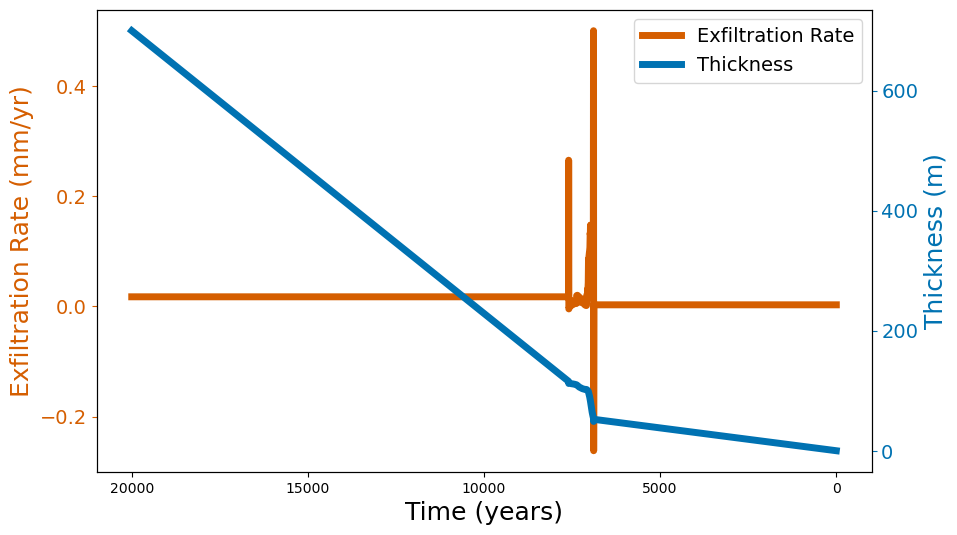

In [205]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Set a consistent line width
line_width = 5

# Plot the exfiltration rate on the primary y-axis
line1, = ax1.plot(site_data['Age'], exfil_value, '-', color='#D55E00', label='Exfiltration Rate', linewidth=line_width)
ax1.set_xlabel('Time (years)', fontsize=18)
ax1.set_ylabel('Exfiltration Rate (mm/yr)', fontsize=18, color='#D55E00')
ax1.tick_params(axis='y', labelsize=14, colors='#D55E00')
ax1.invert_xaxis()  # Invert x-axis so that time decreases to the right
ax1.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
ax1.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Create a secondary y-axis for thickness
ax2 = ax1.twinx()
line2, = ax2.plot(site_data['Age'], site_data['Thickness'], color='#0072B2', label='Thickness', linewidth=line_width)
ax2.set_ylabel('Thickness (m)', fontsize=18, color='#0072B2')
ax2.tick_params(axis='y', labelsize=14, colors='#0072B2')
ax2.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Combine legends and place it in the upper right
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=14)

# Set title
plt.title(f'', fontsize=15)
#plt.savefig("exfiltration_thickness_plot.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

## Storing paleoexfiltration values


In [206]:
# Calculate and store exfiltration values for all the sites

# Initialize an empty DataFrame to store exfiltration values
time_steps = interpolated_df['Age'].unique()
exfiltration_df = pd.DataFrame(index=interpolated_df.index, columns=['Site', 'Age', 'Latitude', 'Longitude', 'Exfiltration (mm/yr)'])

# Ensure exfil_value is reset before looping over sites
exfil_value = None  

for site in interpolated_df['Site'].unique():
    site_data = interpolated_df[interpolated_df['Site'] == site]

    # Compute site-specific deltat
    deltat = (site_data['Age'].max() - site_data['Age'].min())

    # Calculate dhdt (rate of change of ice thickness)
    dhdt = np.gradient(site_data['Thickness'], site_data['Age'])

    # Calculate the exfiltration rate
    exfil_analytic = 2 * (1 - xi) * (rhoi / rhow) * dhdt * (K_t * S * deltat / np.pi) ** 0.5
    exfil_value = exfil_analytic * 1000  # Convert to mm/yr

    # Extract latitude and longitude
    site_lat = site_data['Latm'].iloc[0]
    site_long = site_data['Lonm'].iloc[0]

    # Store values in DataFrame
    exfiltration_df.loc[site_data.index, 'Site'] = site
    exfiltration_df.loc[site_data.index, 'Age'] = site_data['Age']
    exfiltration_df.loc[site_data.index, 'Latitude'] = site_lat
    exfiltration_df.loc[site_data.index, 'Longitude'] = site_long
    exfiltration_df.loc[site_data.index, 'Exfiltration (mm/yr)'] = exfil_value

# Convert columns to appropriate data types
exfiltration_df['Site'] = exfiltration_df['Site'].astype(str)
exfiltration_df['Age'] = exfiltration_df['Age'].astype(float)
exfiltration_df['Latitude'] = exfiltration_df['Latitude'].astype(float)
exfiltration_df['Longitude'] = exfiltration_df['Longitude'].astype(float)
exfiltration_df['Exfiltration (mm/yr)'] = exfiltration_df['Exfiltration (mm/yr)'].astype(float)

# Save to CSV
exfiltration_df.to_csv('paleoexfiltrationperm14lowerCI.csv', index=False)

## East Antarctica Thinning Histories

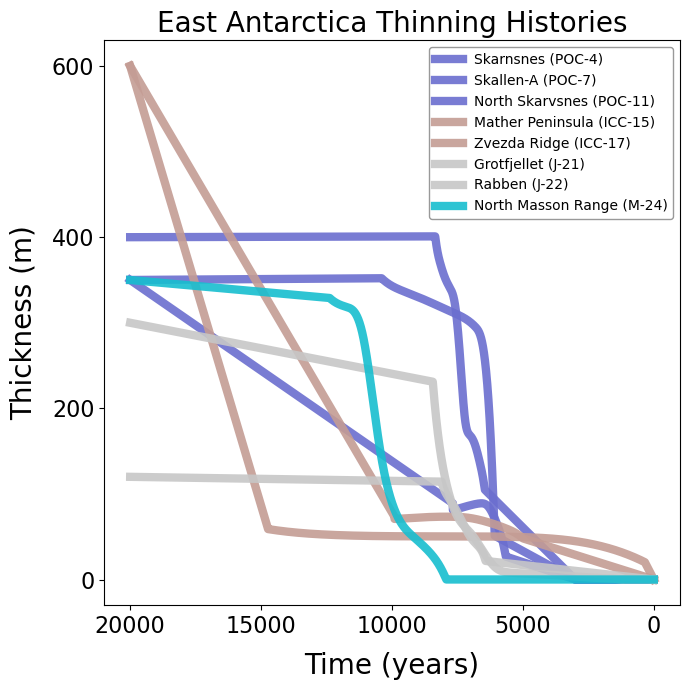

In [251]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    4:  "Skarnsnes (POC-4)",
    7:  "Skallen-A (POC-7)",
    11: "North Skarvsnes (POC-11)", 
    15: "Mather Peninsula (ICC-15)", 
    17: "Zvezda Ridge (ICC-17)",
    21: "Grotfjellet (J-21)", 
    22: "Rabben (J-22)",
    24: "North Masson Range (M-24)"
}

# Basin HEX color key
basin_colors = {
    "Prince_Olav_Coast": "#6b6ecf",
    "Ingrid_Christensen_Coast": "#c49c94",
    "Jutulstraumen": "#c7c7c7",
    "Mawson_Coast": "#17becf",
    # other basins can be added later...
}

# Map each site to its actual basin
site_to_basin = {
    4:  "Prince_Olav_Coast",
    7:  "Prince_Olav_Coast",
    11: "Prince_Olav_Coast",
    15: "Ingrid_Christensen_Coast",
    17: "Ingrid_Christensen_Coast",
    21: "Jutulstraumen",
    22: "Jutulstraumen",
    24: "Mawson_Coast"
}

# Sites to plot
sites_to_plot = [4, 7, 11, 15, 17, 21, 22, 24]

plt.figure(figsize=(7, 7))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],
        color=color,
        linewidth=6,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("East Antarctica Thinning Histories", fontsize=20)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()

# Save figure
plt.savefig("EastAntarcticaThinningHistories.jpg", format="jpg", dpi=700, bbox_inches="tight")
plt.show()


# Transantarctic Mountains Thinning Histories

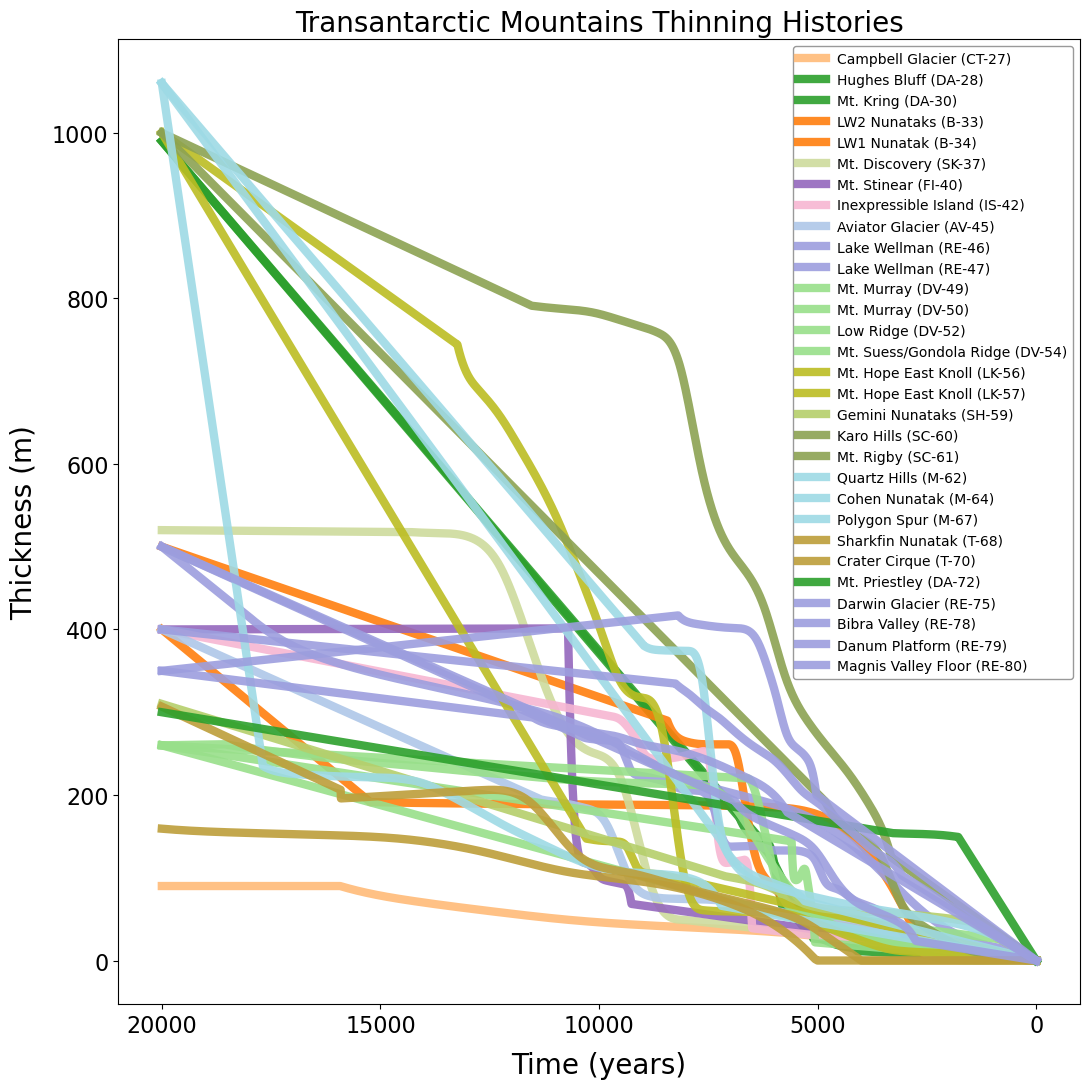

In [260]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    27: "Campbell Glacier (CT-27)",
    28: "Hughes Bluff (DA-28)",
    30: "Mt. Kring (DA-30)", 
    33: "LW2 Nunataks (B-33)", 
    34: "LW1 Nunatak (B-34)",
    37: "Mt. Discovery (SK-37)", 
    40: "Mt. Stinear (FI-40)",
    42: "Inexpressible Island (IS-42)",
    45: "Aviator Glacier (AV-45)", 
    46: "Lake Wellman (RE-46)", 
    47: "Lake Wellman (RE-47)",
    49: "Mt. Murray (DV-49)", 
    50: "Mt. Murray (DV-50)", 
    52: "Low Ridge (DV-52)", 
    54: "Mt. Suess/Gondola Ridge (DV-54)", 
    56: "Mt. Hope East Knoll (LK-56)", 
    57: "Mt. Hope East Knoll (LK-57)", 
    59: "Gemini Nunataks (SH-59)", 
    60: "Karo Hills (SC-60)", 
    61: "Mt. Rigby (SC-61)", 
    62: "Quartz Hills (M-62)", 
    64: "Cohen Nunatak (M-64)", 
    67: "Polygon Spur (M-67)", 
    68: "Sharkfin Nunatak (T-68)", 
    70: "Crater Cirque (T-70)", 
    72: "Mt. Priestley (DA-72)", 
    75: "Darwin Glacier (RE-75)", 
    78: "Bibra Valley (RE-78)", 
    79: "Danum Platform (RE-79)", 
    80: "Magnis Valley Floor (RE-80)", 
}

# Basin HEX color key
basin_colors = {
    "Prince_Olav_Coast": "#6b6ecf",
    "Ingrid_Christensen_Coast": "#c49c94",
    "Jutulstraumen": "#c7c7c7",
    "Mawson_Coast": "#17becf",
    "Campbell-Tinker": "#ffbb78",
    "David": "#2ca02c",
    "Byrd": "#ff7f0e",
    "Skelton": "#cedb9c",
    "Fisher": "#9467bd",
    "Islands": "#f7b6d2",
    "Aviator": "#aec7e8",
    "Ross_East5": "#9c9ede",
    "Dry Valleys": "#98df8a",
    "Lennox-King": "#bcbd22",
    "Shackleton": "#b5cf6b",
    "Scott": "#8ca252",
    "Mercer": "#9edae5",
    "Tucker": "#bd9e39",
    "Jason_Peninsula": "#7f7f7f",
    "Eastern_Graham_Land": "#ff9896",
    "Drygalski": "#d62728",
    "Academy": "#1f77b4",
    "Rutford": "#637939",
    "Hercules": "#8c564b",
    "Foundation": "#c5b0d5",
    "Institute": "#e377c2",
    "Sulzberger": "#8c6d31",
    "Pope": "#5254a3",
    "Walgreen_Coast": "#e7ba52",
    "Lucchitta_Velasco": "#dbdb8d",
    "Pine_Island": "#393b79"
}

# Map each site to its basin
site_to_basin = {
    27: "Campbell-Tinker",
    28: "David",
    30: "David",
    33: "Byrd",
    34: "Byrd",
    37: "Skelton",
    40: "Fisher",
    42: "Islands",
    45: "Aviator",
    46: "Ross_East5",
    47: "Ross_East5",
    49: "Dry Valleys",
    50: "Dry Valleys",
    52: "Dry Valleys",
    54: "Dry Valleys",
    56: "Lennox-King",
    57: "Lennox-King",
    59: "Shackleton",
    60: "Scott",
    61: "Scott",
    62: "Mercer",
    64: "Mercer",
    67: "Mercer",
    68: "Tucker",
    70: "Tucker",
    72: "David",
    75: "Ross_East5",
    78: "Ross_East5",
    79: "Ross_East5",
    80: "Ross_East5"
}

# Sites to plot
sites_to_plot = list(site_labels.keys())

plt.figure(figsize=(11, 11))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],  # keep site labels
        color=color,
        linewidth=6,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Transantarctic Mountains Thinning Histories", fontsize=20)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()


# Save figure
plt.savefig("TransantarcticMountainsThinningHistories.jpg", format="jpg", dpi=700)
plt.show()

# Antarctic Peninsula Thinning Histories 

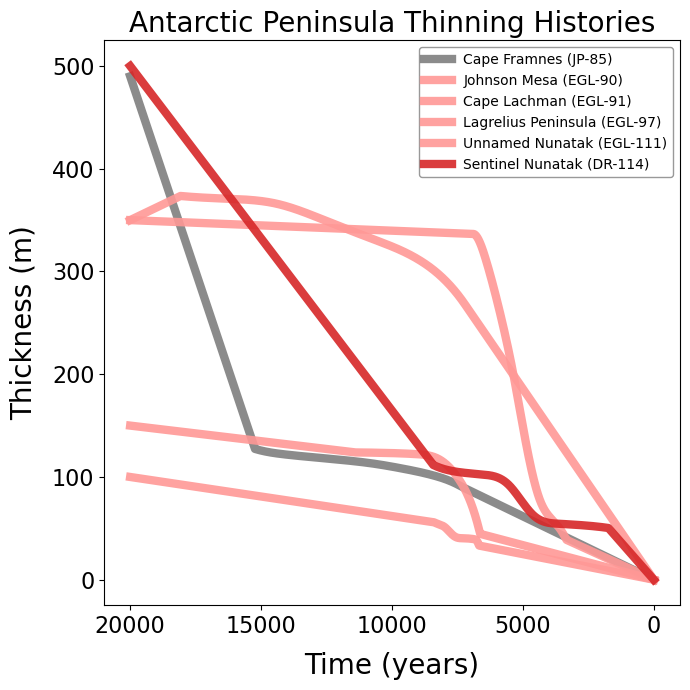

In [262]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    85: "Cape Framnes (JP-85)", 
    90: "Johnson Mesa (EGL-90)", 
    91: "Cape Lachman (EGL-91)", 
    97: "Lagrelius Peninsula (EGL-97)", 
    111: "Unnamed Nunatak (EGL-111)", 
    114: "Sentinel Nunatak (DR-114)", 
}

# Basin HEX color key
basin_colors = {
    "Jason_Peninsula": "#7f7f7f",
    "Eastern_Graham_Land": "#ff9896",
    "Drygalski": "#d62728",
    # add other basins if needed
}

# Map each site to its basin
site_to_basin = {
    85: "Jason_Peninsula",
    90: "Eastern_Graham_Land",
    91: "Eastern_Graham_Land",
    97: "Eastern_Graham_Land",
    111: "Eastern_Graham_Land",
    114: "Drygalski"
}

# Sites to plot
sites_to_plot = list(site_labels.keys())

plt.figure(figsize=(7, 7))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],  # keep site labels
        color=color,
        linewidth=6,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Antarctic Peninsula Thinning Histories", fontsize=20)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()


# Save figure
plt.savefig("AntarcticPeninsulaThinningHistories.jpg", format="jpg", dpi=700)
plt.show()


# Weddell Sea Thinning Histories 

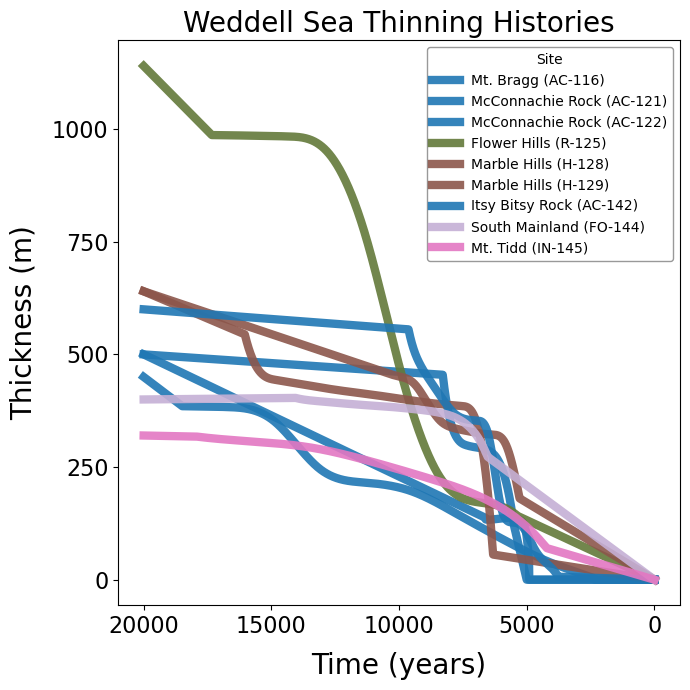

In [263]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    116: "Mt. Bragg (AC-116)", 
    121: "McConnachie Rock (AC-121)", 
    122: "McConnachie Rock (AC-122)", 
    125: "Flower Hills (R-125)", 
    128: "Marble Hills (H-128)", 
    129: "Marble Hills (H-129)", 
    142: "Itsy Bitsy Rock (AC-142)", 
    144: "South Mainland (FO-144)", 
    145: "Mt. Tidd (IN-145)" 
}

# Basin HEX color key
basin_colors = {
    "Academy": "#1f77b4",
    "Rutford": "#637939",
    "Hercules": "#8c564b",
    "Foundation": "#c5b0d5",
    "Institute": "#e377c2"
}

# Map each site to its basin
site_to_basin = {
    116: "Academy",
    121: "Academy",
    122: "Academy",
    125: "Rutford",
    128: "Hercules",
    129: "Hercules",
    142: "Academy",
    144: "Foundation",
    145: "Institute"
}

# Sites to plot
sites_to_plot = list(site_labels.keys())

plt.figure(figsize=(7, 7))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],  # keep site labels
        color=color,
        linewidth=6,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
# plt.title("Weddell Sea Thinning Histories", fontsize=20)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Weddell Sea Thinning Histories", fontsize=20)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray', title="Site")
plt.tight_layout()

# Save figure
plt.savefig("WeddellSeaThinningHistories.jpg", format="jpg", dpi=700)
plt.show()


# Marie Byrd Land Thinning Histories 

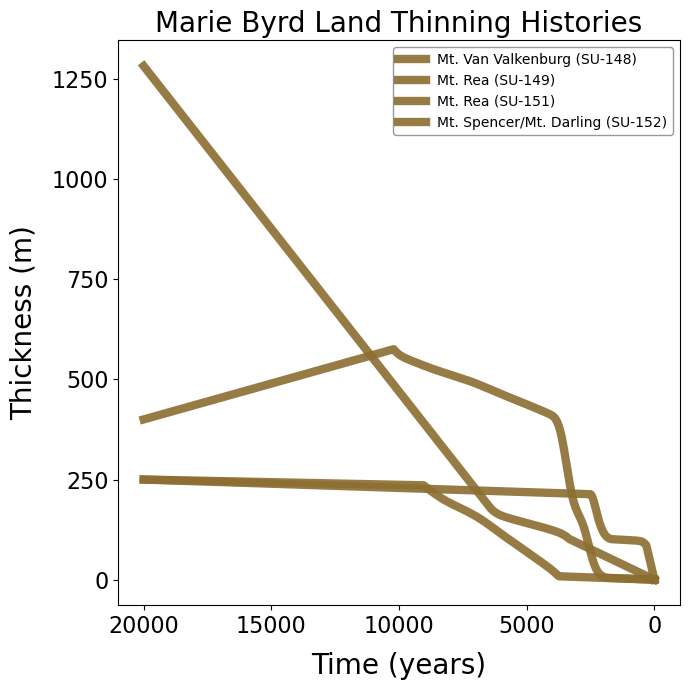

In [264]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    148: "Mt. Van Valkenburg (SU-148)", 
    149: "Mt. Rea (SU-149)", 
    151: "Mt. Rea (SU-151)", 
    152: "Mt. Spencer/Mt. Darling (SU-152)", 
}

# Basin HEX color key
basin_colors = {
    "Sulzberger": "#8c6d31",
    # add other basins if needed
}

# Map each site to its basin
site_to_basin = {
    148: "Sulzberger",
    149: "Sulzberger",
    151: "Sulzberger",
    152: "Sulzberger"
}

# Sites to plot
sites_to_plot = list(site_labels.keys())

plt.figure(figsize=(7, 7))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],  # keep site labels
        color=color,
        linewidth=6,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
plt.title("Marie Byrd Land Thinning Histories", fontsize=20)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()


# Save figure
plt.savefig("MarieByrdLandThinningHistories.jpg", format="jpg", dpi=700)
plt.show()



# Amundsen Sea Thinning Histories

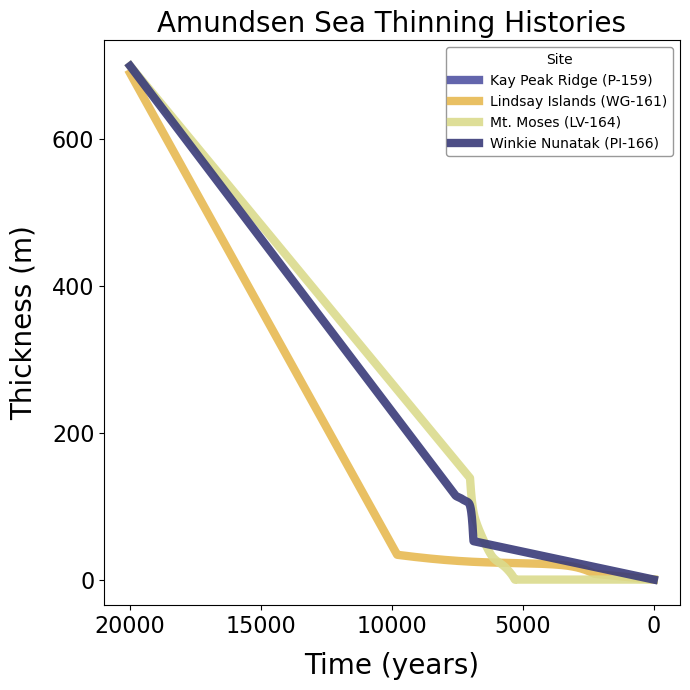

In [266]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    159: "Kay Peak Ridge (P-159)", 
    161: "Lindsay Islands (WG-161)", 
    164: "Mt. Moses (LV-164)", 
    166: "Winkie Nunatak (PI-166)"   
}

# Basin HEX color key
basin_colors = {
    "Pope": "#5254a3",
    "Walgreen_Coast": "#e7ba52",
    "Lucchitta_Velasco": "#dbdb8d",
    "Pine_Island": "#393b79"
}

# Map each site to its basin
site_to_basin = {
    159: "Pope",
    161: "Walgreen_Coast",
    164: "Lucchitta_Velasco",
    166: "Pine_Island"
}

# Sites to plot
sites_to_plot = list(site_labels.keys())

plt.figure(figsize=(7, 7))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],  # keep site labels
        color=color,
        linewidth=6,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
plt.title("Amundsen Sea Thinning Histories", fontsize=20)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray', title="Site")
plt.tight_layout()

# Save figure
plt.savefig("AmundsenSeaThinningHistories.jpg", format="jpg", dpi=700)
plt.show()



### Results figure showing thinning history of interesting sites (>0.5 mmm yr)

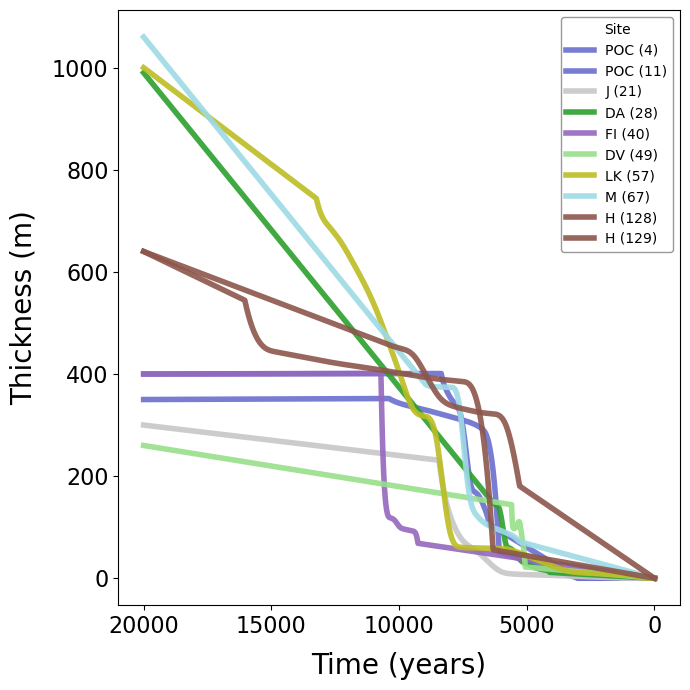

In [267]:
import pandas as pd
import matplotlib.pyplot as plt

# Load interpolated time series
file_path = 'thicknesstimeseriesmean.csv'
interpolated_df = pd.read_csv(file_path)

# Full site label dictionary
site_labels = {
    4:  "POC (4)",
    11: "POC (11)",
    21: "J (21)",
    28: "DA (28)",
    40: "FI (40)",
    49: "DV (49)", 
    57: "LK (57)", 
    67: "M (67)",
    128: "H (128)", 
    129: "H (129)"
}

# Basin HEX color key
basin_colors = {
    "Prince_Olav_Coast": "#6b6ecf",
    "Jutulstraumen": "#c7c7c7",
    "David": "#2ca02c",
    "Fisher": "#9467bd",
    "Dry Valleys": "#98df8a",
    "Lennox-King": "#bcbd22",
    "Mercer": "#9edae5",
    "Hercules": "#8c564b"
}

# Map each site to its basin
site_to_basin = {
    4: "Prince_Olav_Coast",
    11: "Prince_Olav_Coast",
    21: "Jutulstraumen",
    28: "David",
    40: "Fisher",
    49: "Dry Valleys",
    57: "Lennox-King",
    67: "Mercer",
    128: "Hercules",
    129: "Hercules"
}

# Sites to plot
sites_to_plot = list(site_labels.keys())

plt.figure(figsize=(7, 7))

for site in sites_to_plot:
    site_data = interpolated_df[interpolated_df['Site'] == site]
    basin = site_to_basin[site]
    color = basin_colors[basin]

    plt.plot(
        site_data['Age'],
        site_data['Thickness'],
        label=site_labels[site],  # keep site labels
        color=color,
        linewidth=4,
        alpha=0.9
    )

# Formatting
plt.xlabel("Time (years)", fontsize=20, labelpad=10)
plt.ylabel("Thickness (m)", fontsize=20, labelpad=10)
plt.gca().invert_xaxis()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)
plt.legend(fontsize=10, frameon=True, facecolor='white', edgecolor='gray', title="Site")
plt.tight_layout()

plt.savefig("Interestingthinninghistories.pdf", format="pdf", dpi=700)
